## computing the leiden clustering for cell UMAP (joint, WNN)

- Here, the idea is to clustering the cell UMAP with varying resolutions to see if, and how that affects the pseudobulk-by-peaks, ultimately to the peak UMAP

In [1]:
import scanpy as sc
import numpy as np
import pandas as pd
import scipy.sparse as sp

# Import the custom module
import os
import sys
sys.path.append("/hpc/projects/data.science/yangjoon.kim/excellxgene_tutorial_manuscript/celltype_annotation_tutorial/utilities/")
from sankey import sankey
# help(sankey)

In [2]:
# figure parameter setting
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
mpl.rcParams.update(mpl.rcParamsDefault) #Reset rcParams to default

# Editable text and proper LaTeX fonts in illustrator
# matplotlib.rcParams['ps.useafm'] = True
# Editable fonts. 42 is the magic number
mpl.rcParams['pdf.fonttype'] = 42
sns.set(style='whitegrid', context='paper')
# Set default DPI for saved figures
mpl.rcParams['savefig.dpi'] = 600

In [3]:
import logging
# Suppress INFO-level logs for the entire logger
logging.getLogger().setLevel(logging.WARNING)

In [4]:
# define the figure path
figpath = "/hpc/projects/data.science/yangjoon.kim/zebrahub_multiome/zebrahub-multiome-analysis/figures/cell_umap_wnn_leiden_clustering/"
os.makedirs(figpath, exist_ok=True)
sc.settings.figdir = figpath

In [6]:
# import the object
adata = sc.read_h5ad("/hpc/projects/data.science/yangjoon.kim/zebrahub_multiome/data/processed_data/01_Signac_processed/integrated_RNA_ATAC_counts_RNA_leiden_filtered.h5ad")
adata

AnnData object with n_obs × n_vars = 94562 × 32057
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'nCount_ATAC', 'nFeature_ATAC', 'nucleosome_signal', 'nucleosome_percentile', 'TSS.enrichment', 'TSS.percentile', 'nCount_SCT', 'nFeature_SCT', 'global_annotation', 'nCount_peaks_bulk', 'nFeature_peaks_bulk', 'nCount_peaks_celltype', 'nFeature_peaks_celltype', 'nCount_peaks_merged', 'nFeature_peaks_merged', 'SCT.weight', 'peaks_merged.weight', 'nCount_Gene.Activity', 'nFeature_Gene.Activity', 'nCount_peaks_integrated', 'nFeature_peaks_integrated', 'dataset', 'integrated.weight', 'peaks_integrated.weight', 'wsnn_res.0.8', 'seurat_clusters', 'leiden_0.5', 'leiden_0.8', 'leiden_1', 'leiden_1.2', 'leiden_1.5', 'leiden_2', 'leiden_3', 'leiden_4', 'leiden_5', 'leiden_6', 'leiden_7', 'leiden_8', 'leiden_9', 'leiden_10', 'leiden_0.5_merged', 'leiden_0.8_merged', 'leiden_1_merged', 'leiden_1.2_merged', 'leiden_1.5_merged', 'leiden_2_merged', 'leiden_3_merged', 'leiden_4_merged', 'leiden_5_mer

In [9]:
# import an adata for the annotation
adata_anno = sc.read_h5ad("/hpc/projects/data.science/yangjoon.kim/zebrahub_multiome/data/processed_data/01_Signac_processed/integrated_RNA_ATAC_counts_RNA_master_filtered.h5ad")
adata_anno

AnnData object with n_obs × n_vars = 94562 × 32057
    obs: 'orig_ident', 'nCount_RNA', 'nFeature_RNA', 'nCount_ATAC', 'nFeature_ATAC', 'nucleosome_signal', 'nucleosome_percentile', 'TSS_enrichment', 'TSS_percentile', 'nCount_SCT', 'nFeature_SCT', 'global_annotation', 'nCount_peaks_bulk', 'nFeature_peaks_bulk', 'nCount_peaks_celltype', 'nFeature_peaks_celltype', 'nCount_peaks_merged', 'nFeature_peaks_merged', 'SCT_weight', 'peaks_merged_weight', 'nCount_Gene_Activity', 'nFeature_Gene_Activity', 'nCount_peaks_integrated', 'nFeature_peaks_integrated', 'dataset', 'integrated_weight', 'peaks_integrated_weight', 'wsnn_res_0_8', 'seurat_clusters', 'data_source', 'annotation_ML', 'scANVI_zscape', 'annotation_ML_coarse', 'dev_stage'
    var: 'features'
    uns: 'annotation_ML_coarse_colors', 'annotation_ML_colors', 'dataset_colors', 'global_annotation_colors', 'log1p', 'scANVI_zscape_colors'
    obsm: 'X_umap.atac', 'X_umap.rna', 'X_wnn.umap'
    layers: 'counts'

In [10]:
# copy over the important annotations (celltype and timepoints)
adata.obs["annotation_ML_coarse"] = adata.obs_names.map(adata_anno.obs["annotation_ML_coarse"])
adata.obs["dev_stage"] = adata.obs_names.map(adata_anno.obs["dev_stage"])

## computing the connectivities and distances using WSNN (seurat)

In [10]:
# import the distances from WNN (weighted nearest neighbors)
dist_df = pd.read_csv("/hpc/projects/data.science/yangjoon.kim/zebrahub_multiome/data/processed_data/01_Signac_processed/wnn.csv")
dist_df.head()

# Get unique cell names to create the mapping
unique_cells = dist_df['cell_name'].unique()
n_cells = len(unique_cells)
print(f"Will create a {n_cells} x {n_cells} sparse matrix")

# Create a dictionary mapping cell names to row/column indices
cell_to_idx = {cell: idx for idx, cell in enumerate(unique_cells)}

# Initialize sparse matrices for distances and connectivities
# Use LIL format for efficient construction, then convert to CSR
distances = sp.lil_matrix((n_cells, n_cells), dtype=np.float32)
# connectivities = sp.lil_matrix((n_cells, n_cells), dtype=np.float32)

# Fill the matrices
# Note: This vectorized approach is much faster than iterating through rows
cell_indices = [cell_to_idx[name] for name in dist_df['cell_name']]
neighbor_indices = [cell_to_idx[name] for name in dist_df['neighbor_name']]
dist_values = dist_df['distance'].values

# Set the values in the matrices
for i, (cell_idx, neighbor_idx, dist) in enumerate(zip(cell_indices, neighbor_indices, dist_values)):
    # Set distance value
    distances[cell_idx, neighbor_idx] = dist
    
    # Set connectivity value (1 - distance)
    # This is a simple transformation - adjust if you have a better formula
    # connectivities[cell_idx, neighbor_idx] = 1.0 - dist
    
    # Print progress for large datasets
    if i % 1000000 == 0 and i > 0:
        print(f"Processed {i:,} / {len(dist_df):,} entries")

# Convert to CSR format for efficient operations
distances = distances.tocsr()
# connectivities = connectivities.tocsr()

Will create a 95196 x 95196 sparse matrix
Processed 1,000,000 / 1,903,920 entries


In [11]:
# Display info about the dataframe
print(f"DataFrame shape: {dist_df.shape}")
print(f"Total pairs: {len(dist_df)}")
print(f"Number of unique cells: {dist_df['cell_name'].nunique()}")
print(f"Max neighbors per cell: {dist_df.groupby('cell_name').size().max()}")

DataFrame shape: (1903920, 5)
Total pairs: 1903920
Number of unique cells: 95196
Max neighbors per cell: 20


In [12]:
# import the WSNN (n_cells-by-n_cells)
import scipy.io

# Load the matrix in scipy sparse format
input_dir = "/hpc/projects/data.science/yangjoon.kim/zebrahub_multiome/data/processed_data/01_Signac_processed/"
wsnn_matrix = scipy.io.mmread(os.path.join(input_dir, "wsnn_matrix.mtx"))
# Make sure it's CSR format
wsnn_matrix = wsnn_matrix.tocsr()

# Load cell names
with open(os.path.join(input_dir, "cell_names.txt"), "r") as f:
    mtx_cell_names = [line.strip() for line in f]

# Add the WSNN graph as connectivities
adata.obsp['connectivities'] = wsnn_matrix

# # Add a placeholder for distances
# adata.obsp['distances'] = sp.csr_matrix(wsnn_matrix.shape)

In [13]:
# Only check ordering if the sets have the same cells
is_same_order = all(a == b for a, b in zip(adata.obs_names, mtx_cell_names))
print(is_same_order)

True


In [14]:
# add the distances to the adata
adata.obsp['distances'] = distances

In [17]:
# Add the necessary information to adata.uns['neighbors']
adata.uns['neighbors'] = {
    'connectivities_key': 'connectivities',
    'distances_key': 'distances',  # Even if you don't have distances, you need this key
    'params': {
        'method': 'seurat_wnn',
        'n_neighbors': -1  # -1 indicates it's from an external source
    }
}

In [15]:
# check the adata
adata

AnnData object with n_obs × n_vars = 95196 × 32057
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'nCount_ATAC', 'nFeature_ATAC', 'nucleosome_signal', 'nucleosome_percentile', 'TSS.enrichment', 'TSS.percentile', 'nCount_SCT', 'nFeature_SCT', 'global_annotation', 'prediction.score.Lateral_Mesoderm', 'prediction.score.Neural_Crest', 'prediction.score.Somites', 'prediction.score.Epidermal', 'prediction.score.Neural_Anterior', 'prediction.score.Neural_Posterior', 'prediction.score.Endoderm', 'prediction.score.PSM', 'prediction.score.Differentiating_Neurons', 'prediction.score.Adaxial_Cells', 'prediction.score.NMPs', 'prediction.score.Notochord', 'prediction.score.Muscle', 'prediction.score.unassigned', 'prediction.score.max', 'nCount_peaks_bulk', 'nFeature_peaks_bulk', 'nCount_peaks_celltype', 'nFeature_peaks_celltype', 'nCount_peaks_merged', 'nFeature_peaks_merged', 'SCT.weight', 'peaks_merged.weight', 'nCount_Gene.Activity', 'nFeature_Gene.Activity', 'nCount_peaks_integrated', 'nFe

In [16]:
# clean up the adata object obs columns
cols_to_drop = [col for col in adata.obs.columns if "prediction.score" in col]
adata.obs.drop(columns=cols_to_drop, inplace=True)
adata

AnnData object with n_obs × n_vars = 95196 × 32057
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'nCount_ATAC', 'nFeature_ATAC', 'nucleosome_signal', 'nucleosome_percentile', 'TSS.enrichment', 'TSS.percentile', 'nCount_SCT', 'nFeature_SCT', 'global_annotation', 'nCount_peaks_bulk', 'nFeature_peaks_bulk', 'nCount_peaks_celltype', 'nFeature_peaks_celltype', 'nCount_peaks_merged', 'nFeature_peaks_merged', 'SCT.weight', 'peaks_merged.weight', 'nCount_Gene.Activity', 'nFeature_Gene.Activity', 'nCount_peaks_integrated', 'nFeature_peaks_integrated', 'dataset', 'integrated.weight', 'peaks_integrated.weight', 'wsnn_res.0.8', 'seurat_clusters'
    var: 'features'
    obsm: 'X_umap', 'X_umap.atac', 'X_umap.rna', 'X_wnn.umap'
    obsp: 'connectivities', 'distances'

In [20]:
del adata.raw

In [21]:
# save the adata
adata.write_h5ad("/hpc/projects/data.science/yangjoon.kim/zebrahub_multiome/data/processed_data/01_Signac_processed/integrated_RNA_ATAC_counts_RNA_wnn.h5ad")

## Leiden clustering - with different resolutions

In [22]:
res_leiden = [0.5, 0.8, 1, 1.2, 1.5, 2, 3, 4, 5, 6, 7, 8, 9, 10]

for res in res_leiden:
    sc.tl.leiden(adata, resolution=res, 
                 key_added=f"leiden_{res}")
    n_clusters = len(adata.obs[f"leiden_{res}"].unique())
    print(f"Resolution: {res}, number of clusters: {n_clusters}")

adata

Resolution: 0.5, number of clusters: 60
Resolution: 0.8, number of clusters: 65
Resolution: 1, number of clusters: 73
Resolution: 1.2, number of clusters: 80
Resolution: 1.5, number of clusters: 83
Resolution: 2, number of clusters: 92
Resolution: 3, number of clusters: 110
Resolution: 4, number of clusters: 131
Resolution: 5, number of clusters: 142
Resolution: 6, number of clusters: 162
Resolution: 7, number of clusters: 176
Resolution: 8, number of clusters: 188
Resolution: 9, number of clusters: 201
Resolution: 10, number of clusters: 211


AnnData object with n_obs × n_vars = 95196 × 32057
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'nCount_ATAC', 'nFeature_ATAC', 'nucleosome_signal', 'nucleosome_percentile', 'TSS.enrichment', 'TSS.percentile', 'nCount_SCT', 'nFeature_SCT', 'global_annotation', 'nCount_peaks_bulk', 'nFeature_peaks_bulk', 'nCount_peaks_celltype', 'nFeature_peaks_celltype', 'nCount_peaks_merged', 'nFeature_peaks_merged', 'SCT.weight', 'peaks_merged.weight', 'nCount_Gene.Activity', 'nFeature_Gene.Activity', 'nCount_peaks_integrated', 'nFeature_peaks_integrated', 'dataset', 'integrated.weight', 'peaks_integrated.weight', 'wsnn_res.0.8', 'seurat_clusters', 'leiden_0.5', 'leiden_0.8', 'leiden_1', 'leiden_1.2', 'leiden_1.5', 'leiden_2', 'leiden_3', 'leiden_4', 'leiden_5', 'leiden_6', 'leiden_7', 'leiden_8', 'leiden_9', 'leiden_10'
    var: 'features'
    uns: 'neighbors', 'leiden'
    obsm: 'X_umap', 'X_umap.atac', 'X_umap.rna', 'X_wnn.umap'
    obsp: 'connectivities', 'distances'

In [5]:
def group_singletons_seurat_style(
    adata,
    leiden_key: str = "leiden",
    adjacency_key: str = "connectivities",
    merged_key_suffix: str = "merged",
    group_singletons: bool = True,
    random_seed: int = 1
):
    """
    Replicates Seurat's 'GroupSingletons' post-processing step.
    - Finds clusters of size 1 (singletons) in adata.obs[leiden_key].
    - For each singleton, measures average connectivity to each other cluster
      by summing the adjacency submatrix SNN[i_cell, j_cells] and dividing
      by (# i_cells * # j_cells).
    - Reassigns the singleton cell to whichever cluster has the highest connectivity.
    - If there's a tie, picks randomly (set by random_seed).
    - Writes the merged labels to adata.obs[f"{leiden_key}_{merged_key_suffix}"].
    - If group_singletons=False, singletons remain in a “singleton” label.

    Parameters
    ----------
    adata : AnnData
        Your annotated data matrix.
    leiden_key : str
        Column in adata.obs where the initial Leiden (or other) clustering is stored.
    adjacency_key : str
        Key in adata.obsp containing an NxN adjacency matrix (e.g. "connectivities").
        Must be the same dimension as number of cells.
    merged_key_suffix : str
        Suffix to append when creating the merged labels column. The merged labels go
        in adata.obs[f"{leiden_key}_{merged_key_suffix}"].
    group_singletons : bool
        If True, merge singletons. If False, label them all "singleton".
    random_seed : int
        RNG seed for tie-breaking among equally connected clusters.

    Returns
    -------
    None
        (Modifies adata.obs in place, adding a column with merged labels.)
    """
    # Copy cluster labels
    old_labels = adata.obs[leiden_key].astype(str).values  # ensure string
    unique_labels, counts = np.unique(old_labels, return_counts=True)

    # Identify the singleton clusters (size=1)
    singleton_labels = unique_labels[counts == 1]

    # If not grouping them, just mark them as "singleton" and return
    if not group_singletons:
        new_labels = old_labels.copy()
        for s in singleton_labels:
            new_labels[new_labels == s] = "singleton"
        adata.obs[f"{leiden_key}_{merged_key_suffix}"] = new_labels
        adata.obs[f"{leiden_key}_{merged_key_suffix}"] = adata.obs[
            f"{leiden_key}_{merged_key_suffix}"
        ].astype("category")
        return

    # Otherwise, proceed to merge each singleton
    adjacency = adata.obsp[adjacency_key]
    new_labels = old_labels.copy()
    cluster_names = [cl for cl in unique_labels if cl not in singleton_labels]

    rng = np.random.default_rng(seed=random_seed)  # for tie-breaking

    for s_label in singleton_labels:
        i_cells = np.where(new_labels == s_label)[0]
        if len(i_cells) == 0:
            # Possibly already reassigned if something changed mid-loop
            continue

        # Seurat only has 1 cell for a singleton cluster, but let's be robust:
        # We'll compute the average connectivity for all i_cells anyway.
        # Usually i_cells will be length 1.
        sub_row_count = len(i_cells)

        best_cluster = None
        best_conn = -1  # track maximum average connectivity

        for j_label in cluster_names:
            j_cells = np.where(new_labels == j_label)[0]
            if len(j_cells) == 0:
                continue
            # Extract adjacency submatrix
            # shape is (len(i_cells), len(j_cells))
            sub_snn = adjacency[i_cells[:, None], j_cells]
            avg_conn = sub_snn.sum() / (sub_snn.shape[0] * sub_snn.shape[1])
            if np.isclose(avg_conn, best_conn):
                # tie => randomly pick
                if rng.integers(2) == 0:
                    best_cluster = j_label
                    best_conn = avg_conn
            elif avg_conn > best_conn:
                best_cluster = j_label
                best_conn = avg_conn

        if best_cluster is None:
            # If the singleton has zero connectivity to everything, you could:
            # (A) leave it in its own cluster, or
            # (B) label it "disconnected_singleton"
            # We'll leave it as is for now:
            continue

        # Reassign all i_cells to the chosen cluster
        new_labels[i_cells] = best_cluster

    # Store merged labels in adata.obs
    adata.obs[f"{leiden_key}_{merged_key_suffix}"] = new_labels
    # Remove any unused categories
    adata.obs[f"{leiden_key}_{merged_key_suffix}"] = adata.obs[
        f"{leiden_key}_{merged_key_suffix}"
    ].astype("category")
    adata.obs[f"{leiden_key}_{merged_key_suffix}"].cat.remove_unused_categories()
    
    return adata

In [24]:
res_leiden

[0.5, 0.8, 1, 1.2, 1.5, 2, 3, 4, 5, 6, 7, 8, 9, 10]

In [25]:
# compute the merged labels for all the leiden clustering resolutions
for res in res_leiden:
    print(f"Processing Leiden resolution: {res} → merging singletons...")
    adata = group_singletons_seurat_style(
            adata,
            leiden_key=f"leiden_{res}",       # your Leiden column
            adjacency_key="connectivities", # your adjacency
            merged_key_suffix="merged",
            group_singletons=True,
            random_seed=1
)
adata

Processing Leiden resolution: 0.5 → merging singletons...
Processing Leiden resolution: 0.8 → merging singletons...
Processing Leiden resolution: 1 → merging singletons...
Processing Leiden resolution: 1.2 → merging singletons...
Processing Leiden resolution: 1.5 → merging singletons...
Processing Leiden resolution: 2 → merging singletons...
Processing Leiden resolution: 3 → merging singletons...
Processing Leiden resolution: 4 → merging singletons...
Processing Leiden resolution: 5 → merging singletons...
Processing Leiden resolution: 6 → merging singletons...
Processing Leiden resolution: 7 → merging singletons...
Processing Leiden resolution: 8 → merging singletons...
Processing Leiden resolution: 9 → merging singletons...
Processing Leiden resolution: 10 → merging singletons...


AnnData object with n_obs × n_vars = 95196 × 32057
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'nCount_ATAC', 'nFeature_ATAC', 'nucleosome_signal', 'nucleosome_percentile', 'TSS.enrichment', 'TSS.percentile', 'nCount_SCT', 'nFeature_SCT', 'global_annotation', 'nCount_peaks_bulk', 'nFeature_peaks_bulk', 'nCount_peaks_celltype', 'nFeature_peaks_celltype', 'nCount_peaks_merged', 'nFeature_peaks_merged', 'SCT.weight', 'peaks_merged.weight', 'nCount_Gene.Activity', 'nFeature_Gene.Activity', 'nCount_peaks_integrated', 'nFeature_peaks_integrated', 'dataset', 'integrated.weight', 'peaks_integrated.weight', 'wsnn_res.0.8', 'seurat_clusters', 'leiden_0.5', 'leiden_0.8', 'leiden_1', 'leiden_1.2', 'leiden_1.5', 'leiden_2', 'leiden_3', 'leiden_4', 'leiden_5', 'leiden_6', 'leiden_7', 'leiden_8', 'leiden_9', 'leiden_10', 'leiden_0.5_merged', 'leiden_0.8_merged', 'leiden_1_merged', 'leiden_1.2_merged', 'leiden_1.5_merged', 'leiden_2_merged', 'leiden_3_merged', 'leiden_4_merged', 'leiden_5_mer

In [30]:
del adata.raw

In [31]:
# save the adata object
adata.write_h5ad("/hpc/projects/data.science/yangjoon.kim/zebrahub_multiome/data/processed_data/01_Signac_processed/integrated_RNA_ATAC_counts_RNA_leiden.h5ad")

## resumption from here:
- if we want to compute more leiden clustering, we can start from here.

In [6]:
adata = sc.read_h5ad("/hpc/projects/data.science/yangjoon.kim/zebrahub_multiome/data/processed_data/01_Signac_processed/integrated_RNA_ATAC_counts_RNA_leiden_filtered.h5ad")
adata

AnnData object with n_obs × n_vars = 95196 × 32057
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'nCount_ATAC', 'nFeature_ATAC', 'nucleosome_signal', 'nucleosome_percentile', 'TSS.enrichment', 'TSS.percentile', 'nCount_SCT', 'nFeature_SCT', 'global_annotation', 'nCount_peaks_bulk', 'nFeature_peaks_bulk', 'nCount_peaks_celltype', 'nFeature_peaks_celltype', 'nCount_peaks_merged', 'nFeature_peaks_merged', 'SCT.weight', 'peaks_merged.weight', 'nCount_Gene.Activity', 'nFeature_Gene.Activity', 'nCount_peaks_integrated', 'nFeature_peaks_integrated', 'dataset', 'integrated.weight', 'peaks_integrated.weight', 'wsnn_res.0.8', 'seurat_clusters', 'leiden_0.5', 'leiden_0.8', 'leiden_1', 'leiden_1.2', 'leiden_1.5', 'leiden_2', 'leiden_3', 'leiden_4', 'leiden_5', 'leiden_6', 'leiden_7', 'leiden_8', 'leiden_9', 'leiden_10', 'leiden_0.5_merged', 'leiden_0.8_merged', 'leiden_1_merged', 'leiden_1.2_merged', 'leiden_1.5_merged', 'leiden_2_merged', 'leiden_3_merged', 'leiden_4_merged', 'leiden_5_mer

In [10]:
res_leiden = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7]

for res in res_leiden:
    sc.tl.leiden(adata, resolution=res, 
                 key_added=f"leiden_{res}")
    n_clusters = len(adata.obs[f"leiden_{res}"].unique())
    print(f"Resolution: {res}, number of clusters: {n_clusters}")

adata

/tmp/ipykernel_813637/3455798585.py:4: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata, resolution=res,


Resolution: 0.1, number of clusters: 38
Resolution: 0.2, number of clusters: 46
Resolution: 0.3, number of clusters: 49
Resolution: 0.4, number of clusters: 54
Resolution: 0.5, number of clusters: 60
Resolution: 0.6, number of clusters: 61
Resolution: 0.7, number of clusters: 62


AnnData object with n_obs × n_vars = 95196 × 32057
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'nCount_ATAC', 'nFeature_ATAC', 'nucleosome_signal', 'nucleosome_percentile', 'TSS.enrichment', 'TSS.percentile', 'nCount_SCT', 'nFeature_SCT', 'global_annotation', 'nCount_peaks_bulk', 'nFeature_peaks_bulk', 'nCount_peaks_celltype', 'nFeature_peaks_celltype', 'nCount_peaks_merged', 'nFeature_peaks_merged', 'SCT.weight', 'peaks_merged.weight', 'nCount_Gene.Activity', 'nFeature_Gene.Activity', 'nCount_peaks_integrated', 'nFeature_peaks_integrated', 'dataset', 'integrated.weight', 'peaks_integrated.weight', 'wsnn_res.0.8', 'seurat_clusters', 'leiden_0.5', 'leiden_0.8', 'leiden_1', 'leiden_1.2', 'leiden_1.5', 'leiden_2', 'leiden_3', 'leiden_4', 'leiden_5', 'leiden_6', 'leiden_7', 'leiden_8', 'leiden_9', 'leiden_10', 'leiden_0.5_merged', 'leiden_0.8_merged', 'leiden_1_merged', 'leiden_1.2_merged', 'leiden_1.5_merged', 'leiden_2_merged', 'leiden_3_merged', 'leiden_4_merged', 'leiden_5_mer

In [11]:
# compute the merged labels for all the leiden clustering resolutions
for res in res_leiden:
    print(f"Processing Leiden resolution: {res} → merging singletons...")
    adata = group_singletons_seurat_style(
            adata,
            leiden_key=f"leiden_{res}",       # your Leiden column
            adjacency_key="connectivities", # your adjacency
            merged_key_suffix="merged",
            group_singletons=True,
            random_seed=1
)
adata

Processing Leiden resolution: 0.1 → merging singletons...
Processing Leiden resolution: 0.2 → merging singletons...
Processing Leiden resolution: 0.3 → merging singletons...
Processing Leiden resolution: 0.4 → merging singletons...
Processing Leiden resolution: 0.5 → merging singletons...
Processing Leiden resolution: 0.6 → merging singletons...
Processing Leiden resolution: 0.7 → merging singletons...


AnnData object with n_obs × n_vars = 95196 × 32057
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'nCount_ATAC', 'nFeature_ATAC', 'nucleosome_signal', 'nucleosome_percentile', 'TSS.enrichment', 'TSS.percentile', 'nCount_SCT', 'nFeature_SCT', 'global_annotation', 'nCount_peaks_bulk', 'nFeature_peaks_bulk', 'nCount_peaks_celltype', 'nFeature_peaks_celltype', 'nCount_peaks_merged', 'nFeature_peaks_merged', 'SCT.weight', 'peaks_merged.weight', 'nCount_Gene.Activity', 'nFeature_Gene.Activity', 'nCount_peaks_integrated', 'nFeature_peaks_integrated', 'dataset', 'integrated.weight', 'peaks_integrated.weight', 'wsnn_res.0.8', 'seurat_clusters', 'leiden_0.5', 'leiden_0.8', 'leiden_1', 'leiden_1.2', 'leiden_1.5', 'leiden_2', 'leiden_3', 'leiden_4', 'leiden_5', 'leiden_6', 'leiden_7', 'leiden_8', 'leiden_9', 'leiden_10', 'leiden_0.5_merged', 'leiden_0.8_merged', 'leiden_1_merged', 'leiden_1.2_merged', 'leiden_1.5_merged', 'leiden_2_merged', 'leiden_3_merged', 'leiden_4_merged', 'leiden_5_mer

In [7]:
# redo the leiden clustering with the new resolutions
res_leiden = [0.01, 0.03, 0.05]

for res in res_leiden:
    sc.tl.leiden(adata, resolution=res, 
                 key_added=f"leiden_{res}")
    n_clusters = len(adata.obs[f"leiden_{res}"].unique())
    print(f"Resolution: {res}, number of clusters: {n_clusters}")

adata


/tmp/ipykernel_3689318/3243814589.py:5: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata, resolution=res,


Resolution: 0.01, number of clusters: 28
Resolution: 0.03, number of clusters: 31
Resolution: 0.05, number of clusters: 33


AnnData object with n_obs × n_vars = 95196 × 32057
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'nCount_ATAC', 'nFeature_ATAC', 'nucleosome_signal', 'nucleosome_percentile', 'TSS.enrichment', 'TSS.percentile', 'nCount_SCT', 'nFeature_SCT', 'global_annotation', 'nCount_peaks_bulk', 'nFeature_peaks_bulk', 'nCount_peaks_celltype', 'nFeature_peaks_celltype', 'nCount_peaks_merged', 'nFeature_peaks_merged', 'SCT.weight', 'peaks_merged.weight', 'nCount_Gene.Activity', 'nFeature_Gene.Activity', 'nCount_peaks_integrated', 'nFeature_peaks_integrated', 'dataset', 'integrated.weight', 'peaks_integrated.weight', 'wsnn_res.0.8', 'seurat_clusters', 'leiden_0.5', 'leiden_0.8', 'leiden_1', 'leiden_1.2', 'leiden_1.5', 'leiden_2', 'leiden_3', 'leiden_4', 'leiden_5', 'leiden_6', 'leiden_7', 'leiden_8', 'leiden_9', 'leiden_10', 'leiden_0.5_merged', 'leiden_0.8_merged', 'leiden_1_merged', 'leiden_1.2_merged', 'leiden_1.5_merged', 'leiden_2_merged', 'leiden_3_merged', 'leiden_4_merged', 'leiden_5_mer

In [8]:
# compute the merged labels for all the leiden clustering resolutions
for res in res_leiden:
    print(f"Processing Leiden resolution: {res} → merging singletons...")
    adata = group_singletons_seurat_style(
            adata,
            leiden_key=f"leiden_{res}",       # your Leiden column
            adjacency_key="connectivities", # your adjacency
            merged_key_suffix="merged",
            group_singletons=True,
            random_seed=1
)
adata

Processing Leiden resolution: 0.01 → merging singletons...
Processing Leiden resolution: 0.03 → merging singletons...
Processing Leiden resolution: 0.05 → merging singletons...


AnnData object with n_obs × n_vars = 95196 × 32057
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'nCount_ATAC', 'nFeature_ATAC', 'nucleosome_signal', 'nucleosome_percentile', 'TSS.enrichment', 'TSS.percentile', 'nCount_SCT', 'nFeature_SCT', 'global_annotation', 'nCount_peaks_bulk', 'nFeature_peaks_bulk', 'nCount_peaks_celltype', 'nFeature_peaks_celltype', 'nCount_peaks_merged', 'nFeature_peaks_merged', 'SCT.weight', 'peaks_merged.weight', 'nCount_Gene.Activity', 'nFeature_Gene.Activity', 'nCount_peaks_integrated', 'nFeature_peaks_integrated', 'dataset', 'integrated.weight', 'peaks_integrated.weight', 'wsnn_res.0.8', 'seurat_clusters', 'leiden_0.5', 'leiden_0.8', 'leiden_1', 'leiden_1.2', 'leiden_1.5', 'leiden_2', 'leiden_3', 'leiden_4', 'leiden_5', 'leiden_6', 'leiden_7', 'leiden_8', 'leiden_9', 'leiden_10', 'leiden_0.5_merged', 'leiden_0.8_merged', 'leiden_1_merged', 'leiden_1.2_merged', 'leiden_1.5_merged', 'leiden_2_merged', 'leiden_3_merged', 'leiden_4_merged', 'leiden_5_mer

In [9]:
adata.var = adata.var.reset_index()

In [10]:
# print the number of clusters for each leiden clustering resolution
res_leiden = [0.01, 0.03, 0.05, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7]
for res in res_leiden:
    print(f"the number of clusters for {res} are:", len(adata.obs[f"leiden_{res}_merged"].unique()))

the number of clusters for 0.01 are: 6
the number of clusters for 0.03 are: 9
the number of clusters for 0.05 are: 11
the number of clusters for 0.1 are: 16
the number of clusters for 0.2 are: 24
the number of clusters for 0.3 are: 27
the number of clusters for 0.4 are: 32
the number of clusters for 0.5 are: 38
the number of clusters for 0.6 are: 39
the number of clusters for 0.7 are: 40


In [11]:
del adata.raw

In [12]:
adata.write_h5ad("/hpc/projects/data.science/yangjoon.kim/zebrahub_multiome/data/processed_data/01_Signac_processed/integrated_RNA_ATAC_counts_RNA_leiden.h5ad")

In [38]:
# sc.pl.embedding(adata, basis="X_wnn.umap",
#                 color=["leiden_0.8_merged", "leiden_1_merged","leiden_4_merged","leiden_10_merged"], legend_loc=None)

In [41]:
# plot the number of cells distribution for each leiden clustering resolution
for res in res_leiden:
    adata.obs[f"leiden_{res}_merged"].value_counts().hist(bins=40, alpha=0.7)
    
# plt.show()

In [15]:
# Define fixed bin edges to make bin size consistent
bin_edges = np.histogram_bin_edges(adata.obs["leiden_0.01_merged"].value_counts(), bins=40)
bin_edges

array([   99.   ,  1310.625,  2522.25 ,  3733.875,  4945.5  ,  6157.125,
        7368.75 ,  8580.375,  9792.   , 11003.625, 12215.25 , 13426.875,
       14638.5  , 15850.125, 17061.75 , 18273.375, 19485.   , 20696.625,
       21908.25 , 23119.875, 24331.5  , 25543.125, 26754.75 , 27966.375,
       29178.   , 30389.625, 31601.25 , 32812.875, 34024.5  , 35236.125,
       36447.75 , 37659.375, 38871.   , 40082.625, 41294.25 , 42505.875,
       43717.5  , 44929.125, 46140.75 , 47352.375, 48564.   ])

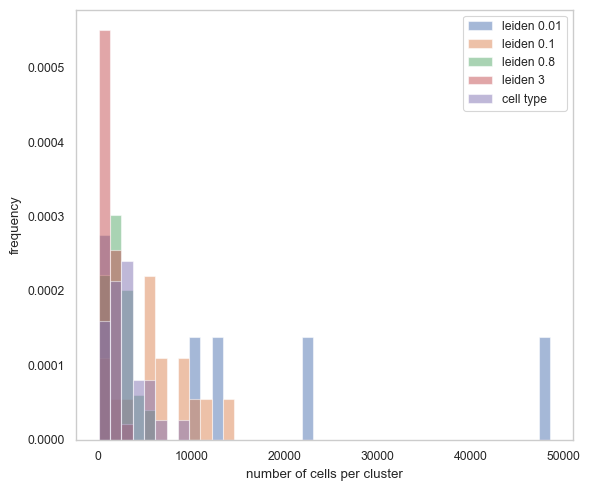

In [20]:
# # plot the number of cells distribution for each leiden clustering resolution
# res_leiden = [0.01, 0.1, 0.8, 3]
# for res in res_leiden:
#     adata.obs[f"leiden_{res}_merged"].value_counts().hist(bins=40, alpha=0.5, density=True)
# adata.obs["annotation_ML_coarse"].value_counts().hist(bins=40, alpha=0.5, density=True)

# plt.legend(res_leiden)
# plt.grid(False)
# plt.xlabel("number of cells per cluster")
# plt.ylabel("frequency")
# plt.savefig(figpath+"hist_num_cells_leiden_clusters_5res.pdf")
# plt.show()

# Initialize the figure
plt.figure(figsize=(6, 5))

# Define resolution and legend labels
res_leiden = [0.01, 0.1, 0.8, 3]
labels = []

# Plot histograms for each leiden resolution
for res in res_leiden:
    counts = adata.obs[f"leiden_{res}_merged"].value_counts()
    plt.hist(counts, bins=bin_edges, alpha=0.5, density=True, label=f"leiden {res}")
    labels.append(f"leiden {res}")

# Plot histogram for cell type annotation
celltype_counts = adata.obs["annotation_ML_coarse"].value_counts()
plt.hist(celltype_counts, bins=bin_edges, alpha=0.5, density=True, label="cell type")
labels.append("cell type")

# Final touches
plt.legend()
plt.grid(False)
plt.xlabel("number of cells per cluster")
plt.ylabel("frequency")
plt.tight_layout()
plt.savefig(figpath + "hist_num_cells_leiden_clusters_5res.pdf")
plt.show()


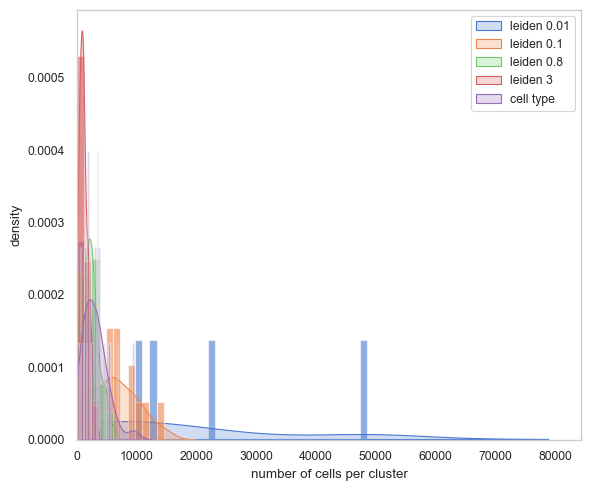

In [28]:
plt.figure(figsize=(6, 5))
res_leiden = [0.01, 0.1, 0.8, 3]
colors = sns.color_palette("muted", n_colors=len(res_leiden) + 1)

# Estimate common bin edges using all counts combined
all_counts = []
for res in res_leiden:
    counts = adata.obs[f"leiden_{res}_merged"].value_counts()
    all_counts.extend(counts)
all_counts.extend(adata.obs["annotation_ML_coarse"].value_counts())
bin_edges = np.histogram_bin_edges(all_counts, bins=40)

# Plot histograms + KDEs for each leiden resolution
for i, res in enumerate(res_leiden):
    counts = adata.obs[f"leiden_{res}_merged"].value_counts()
    # plt.hist(counts, bins=40, density=True, alpha=0.7, color=colors[i])
    plt.hist(counts, bins=bin_edges, density=True, alpha=0.6, color=colors[i])
    sns.kdeplot(counts, fill=True, bw_adjust=0.8, label=f"leiden {res}", color=colors[i])

# Plot for cell type
celltype_counts = adata.obs["annotation_ML_coarse"].value_counts()
plt.hist(celltype_counts, bins=40, density=True, alpha=0.3, color=colors[-1])
sns.kdeplot(celltype_counts, fill=True, bw_adjust=1, label="cell type", color=colors[-1])

# Trim x-axis to non-negative values
plt.xlim(0, None)

# Final touches
plt.xlabel("number of cells per cluster")
plt.ylabel("density")
plt.legend()
plt.grid(False)
plt.tight_layout()
plt.savefig(figpath + "kde_hist_num_cells_leiden_clusters_5res.pdf")
plt.show()


In [29]:
figpath

'/hpc/projects/data.science/yangjoon.kim/zebrahub_multiome/zebrahub-multiome-analysis/figures/cell_umap_wnn_leiden_clustering/'

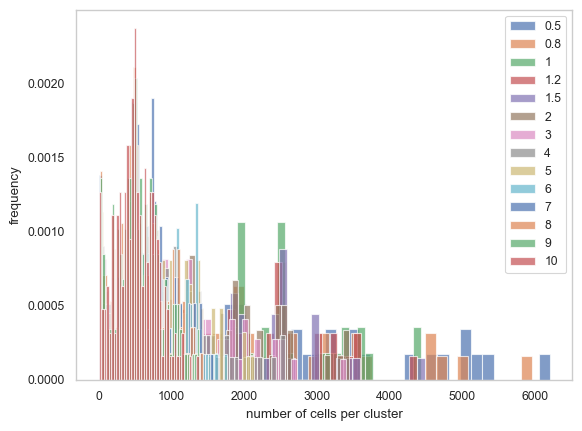

In [50]:
# plot the number of cells distribution for each leiden clustering resolution
for res in res_leiden:
    adata.obs[f"leiden_{res}_merged"].value_counts().hist(bins=40, alpha=0.5, density=True)

plt.legend(res_leiden)
plt.grid(False)
plt.xlabel("number of cells per cluster")
plt.ylabel("frequency")
plt.savefig(figpath+"hist_num_cells_leiden_clusters.pdf")
plt.show()

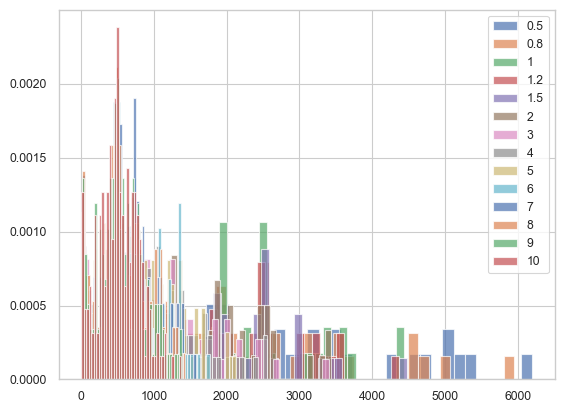

In [ ]:
# plot the number of cells distribution for each leiden clustering resolution
# with kernel density estimation
for res in res_leiden:
    adata.obs[f"leiden_{res}_merged"].value_counts().hist(bins=40, alpha=0.7, density=True)

plt.legend(res_leiden)
plt.show()

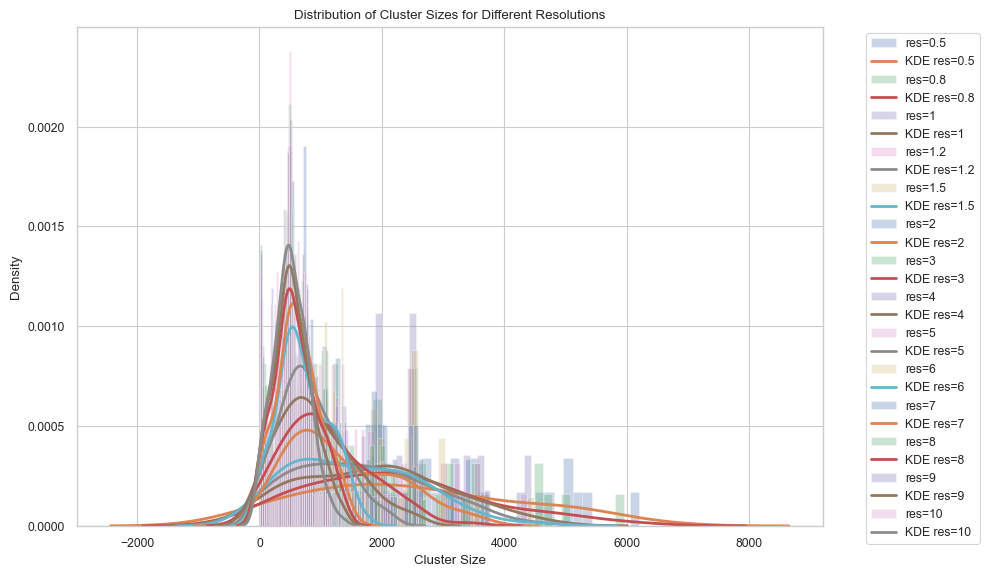

In [47]:
# %%

# plot the number of cells distribution for each leiden clustering resolution
# with kernel density estimation
# for res in res_leiden:
#     adata.obs[f"leiden_{res}_merged"].value_counts().hist(bins=40, alpha=0.7, density=True)

# plt.legend(res_leiden)
# plt.show()

plt.figure(figsize=(10, 6))

for res in res_leiden:
    # Get the cluster sizes
    cluster_sizes = adata.obs[f"leiden_{res}_merged"].value_counts()
    
    # Plot histogram
    cluster_sizes.hist(bins=40, alpha=0.3, density=True, label=f'res={res}')
    
    # Add KDE curve
    sns.kdeplot(data=cluster_sizes, linewidth=2, label=f'KDE res={res}')

plt.xlabel('Cluster Size')
plt.ylabel('Density')
plt.title('Distribution of Cluster Sizes for Different Resolutions')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [52]:
# adata.write_h5ad("/hpc/projects/data.science/yangjoon.kim/zebrahub_multiome/data/processed_data/01_Signac_processed/integrated_RNA_ATAC_counts_RNA_leiden.h5ad")

## plot the sankey diagram


In [44]:
# a color palette for the "coarse" grained celltype annotation ("annotation_ML_coarse")
cell_type_color_dict = {
    'NMPs': '#8dd3c7',
    'PSM': '#008080',
    'differentiating_neurons': '#bebada',
    'endocrine_pancreas': '#fb8072',
    'endoderm': '#80b1d3',
    'enteric_neurons': '#fdb462',
    'epidermis': '#b3de69',
    'fast_muscle': '#df4b9b',
    'floor_plate': '#d9d9d9',
    'hatching_gland': '#bc80bd',
    'heart_myocardium': '#ccebc5',
    'hemangioblasts': '#ffed6f',
    'hematopoietic_vasculature': '#e41a1c',
    'hindbrain': '#377eb8',
    'lateral_plate_mesoderm': '#4daf4a',
    'midbrain_hindbrain_boundary': '#984ea3',
    'muscle': '#ff7f00',
    'neural': '#e6ab02',
    'neural_crest': '#a65628',
    'neural_floor_plate': '#66a61e',
    'neural_optic': '#999999',
    'neural_posterior': '#393b7f',
    'neural_telencephalon': '#fdcdac',
    'neurons': '#cbd5e8',
    'notochord': '#f4cae4',
    'optic_cup': '#c0c000',
    'pharyngeal_arches': '#fff2ae',
    'primordial_germ_cells': '#f1e2cc',
    'pronephros': '#cccccc',
    'somites': '#1b9e77',
    'spinal_cord': '#d95f02',
    'tail_bud': '#7570b3'
}

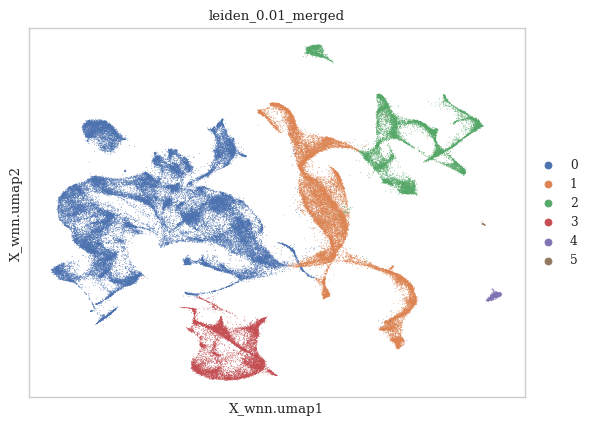

In [36]:
sc.pl.embedding(adata, basis="X_wnn.umap", color="leiden_0.01_merged")

In [59]:
# from collections import defaultdict
# import matplotlib
# matplotlib.use('Agg')
# import matplotlib.pyplot as plt
# import numpy as np
# import pandas as pd
# import seaborn as sns

def check_data_matches_labels(labels, data, side):
    if len(labels > 0):
        if isinstance(data, list):
            data = set(data)
        if isinstance(data, pd.Series):
            data = set(data.unique().tolist())
        if isinstance(labels, list):
            labels = set(labels)
        if labels != data:
            msg = "\n"
            if len(labels) <= 20:
                msg = "Labels: " + ",".join(labels) + "\n"
            if len(data) < 20:
                msg += "Data: " + ",".join(data)
            raise LabelMismatch('{0} labels and data do not match.{1}'.format(side, msg))


def sankey(left, right, leftWeight=None, rightWeight=None, colorDict=None,
           leftLabels=None, rightLabels=None, aspect=4, rightColor=False,
           fontsize=14, figureName=None, closePlot=False, threshold=None):
    '''
    Make Sankey Diagram showing flow from left-->right

    Inputs:
        left = NumPy array of object labels on the left of the diagram
        right = NumPy array of corresponding labels on the right of the diagram
            len(right) == len(left)
        leftWeight = NumPy array of weights for each strip starting from the
            left of the diagram, if not specified 1 is assigned
        rightWeight = NumPy array of weights for each strip starting from the
            right of the diagram, if not specified the corresponding leftWeight
            is assigned
        colorDict = Dictionary of colors to use for each label
            {'label':'color'}
        leftLabels = order of the left labels in the diagram
        rightLabels = order of the right labels in the diagram
        aspect = vertical extent of the diagram in units of horizontal extent
        rightColor = If true, each strip in the diagram will be be colored
                    according to its left label
    Ouput:
        None
    '''
    if leftWeight is None:
        leftWeight = []
    if rightWeight is None:
        rightWeight = []
    if leftLabels is None:
        leftLabels = []
    if rightLabels is None:
        rightLabels = []
    if threshold is None:
        threshold = 0
    # Check weights
    if len(leftWeight) == 0:
        leftWeight = np.ones(len(left))

    if len(rightWeight) == 0:
        rightWeight = leftWeight

    plt.figure()
    plt.rc('text', usetex=False)
    plt.rc('font', family='serif')

    # Create Dataframe
    if isinstance(left, pd.Series):
        left = left.reset_index(drop=True)
    if isinstance(right, pd.Series):
        right = right.reset_index(drop=True)
    dataFrame = pd.DataFrame({'left': left, 'right': right, 'leftWeight': leftWeight,
                              'rightWeight': rightWeight}, index=range(len(left)))

    if len(dataFrame[(dataFrame.left.isnull()) | (dataFrame.right.isnull())]):
        raise NullsInFrame('Sankey graph does not support null values.')


    # Identify all labels that appear 'left' or 'right'
    allLabels = pd.Series(np.r_[dataFrame.left.unique(), dataFrame.right.unique()]).unique()

    # Identify left labels
    if len(leftLabels) == 0:
        leftLabels = pd.Series(dataFrame.left.unique()).unique()
    else:
        check_data_matches_labels(leftLabels, dataFrame['left'], 'left')

    # Identify right labels
    if len(rightLabels) == 0:
        rightLabels = pd.Series(dataFrame.right.unique()).unique()
    else:
        check_data_matches_labels(leftLabels, dataFrame['right'], 'right')

    # If no colorDict given, make one
    if colorDict is None:
        colorDict = {}
        palette = "hls"
        colorPalette = sns.color_palette(palette, len(allLabels))
        for i, label in enumerate(allLabels):
            colorDict[label] = colorPalette[i]
    else:
        missing = [label for label in allLabels if label not in colorDict.keys()]
        if missing:
            msg = "The colorDict parameter is missing values for the following labels : "
            msg += '{}'.format(', '.join(missing))
            raise ValueError(msg)

    # Determine widths of individual strips
    ns_l = {}
    ns_r = {}
    for leftLabel in leftLabels:
        leftDict = {}
        rightDict = {}
        for rightLabel in rightLabels:
            # compute the link values for left and right incorporating the left/right weights
            left_link_value = dataFrame[(dataFrame.left == leftLabel) & (dataFrame.right == rightLabel)].leftWeight.sum()
            right_link_value = dataFrame[(dataFrame.left == leftLabel) & (dataFrame.right == rightLabel)].rightWeight.sum()
            # only add the link_values that are larger than the threshold
            if left_link_value > threshold and right_link_value > threshold:
                leftDict[rightLabel] = dataFrame[(dataFrame.left == leftLabel) & (dataFrame.right == rightLabel)].leftWeight.sum()
                rightDict[rightLabel] = dataFrame[(dataFrame.left == leftLabel) & (dataFrame.right == rightLabel)].rightWeight.sum()
            else:
                pass
                #leftDict[rightLabel] = 0
                #rightDict[rightLabel] = 0
        ns_l[leftLabel] = leftDict
        ns_r[leftLabel] = rightDict  
   

    # Determine positions of left label patches and total widths
    leftWidths = defaultdict()
    for i, leftLabel in enumerate(leftLabels):
        myD = {}
        myD['left'] = dataFrame[dataFrame.left == leftLabel].leftWeight.sum()
        if i == 0:
            myD['bottom'] = 0
            myD['top'] = myD['left']
        else:
            myD['bottom'] = leftWidths[leftLabels[i - 1]]['top'] + 0.02 * dataFrame.leftWeight.sum()
            myD['top'] = myD['bottom'] + myD['left']
            topEdge = myD['top']
        leftWidths[leftLabel] = myD

    # Determine positions of right label patches and total widths
    rightWidths = defaultdict()
    for i, rightLabel in enumerate(rightLabels):
        myD = {}
        myD['right'] = dataFrame[dataFrame.right == rightLabel].rightWeight.sum()
        if i == 0:
            myD['bottom'] = 0
            myD['top'] = myD['right']
        else:
            myD['bottom'] = rightWidths[rightLabels[i - 1]]['top'] + 0.02 * dataFrame.rightWeight.sum()
            myD['top'] = myD['bottom'] + myD['right']
            topEdge = myD['top']
        rightWidths[rightLabel] = myD

    # Total vertical extent of diagram
    # xMax = topEdge / aspect
    # Get total heights for left and right
    left_total_height = sum([leftWidths[l]['left'] for l in leftLabels])
    right_total_height = sum([rightWidths[r]['right'] for r in rightLabels])

    # Use the max of the two to normalize both sides to same height
    total_height = max(left_total_height, right_total_height)

    # Rescale left and right bar positions to match
    def rescale_heights(widths_dict, key):
        cumulative = 0
        for label in widths_dict:
            h = widths_dict[label][key]
            widths_dict[label]['bottom'] = cumulative
            widths_dict[label]['top'] = cumulative + h
            cumulative += h + 0.02 * total_height  # spacing
        return widths_dict

    leftWidths = rescale_heights(leftWidths, 'left')
    rightWidths = rescale_heights(rightWidths, 'right')

    # Now use total_height for axis scaling
    xMax = total_height / aspect

    # Draw vertical bars on left and right of each  label's section & print label
    for leftLabel in leftLabels:
        plt.fill_between(
            [-0.02 * xMax, 0],
            2 * [leftWidths[leftLabel]['bottom']],
            2 * [leftWidths[leftLabel]['bottom'] + leftWidths[leftLabel]['left']],
            color=colorDict[leftLabel],
            alpha=0.99
        )
        plt.text(
            -0.05 * xMax,
            leftWidths[leftLabel]['bottom'] + 0.5 * leftWidths[leftLabel]['left'],
            leftLabel,
            {'ha': 'right', 'va': 'center'},
            fontsize=fontsize
        )
    for rightLabel in rightLabels:
        plt.fill_between(
            [xMax, 1.02 * xMax], 2 * [rightWidths[rightLabel]['bottom']],
            2 * [rightWidths[rightLabel]['bottom'] + rightWidths[rightLabel]['right']],
            color=colorDict[rightLabel],
            alpha=0.99
        )
        plt.text(
            1.05 * xMax,
            rightWidths[rightLabel]['bottom'] + 0.5 * rightWidths[rightLabel]['right'],
            rightLabel,
            {'ha': 'left', 'va': 'center'},
            fontsize=fontsize
        )

    # Plot strips
    for leftLabel in leftLabels:
        for rightLabel in rightLabels:
            labelColor = leftLabel
            if rightColor:
                labelColor = rightLabel
            if len(dataFrame[(dataFrame.left == leftLabel) & (dataFrame.right == rightLabel)]) > threshold:
                # Create array of y values for each strip, half at left value,
                # half at right, convolve
                ys_d = np.array(50 * [leftWidths[leftLabel]['bottom']] + 50 * [rightWidths[rightLabel]['bottom']])
                ys_d = np.convolve(ys_d, 0.05 * np.ones(20), mode='valid')
                ys_d = np.convolve(ys_d, 0.05 * np.ones(20), mode='valid')
                ys_u = np.array(50 * [leftWidths[leftLabel]['bottom'] + ns_l[leftLabel][rightLabel]] + 50 * [rightWidths[rightLabel]['bottom'] + ns_r[leftLabel][rightLabel]])
                ys_u = np.convolve(ys_u, 0.05 * np.ones(20), mode='valid')
                ys_u = np.convolve(ys_u, 0.05 * np.ones(20), mode='valid')

                # Update bottom edges at each label so next strip starts at the right place
                leftWidths[leftLabel]['bottom'] += ns_l[leftLabel][rightLabel]
                rightWidths[rightLabel]['bottom'] += ns_r[leftLabel][rightLabel]
                plt.fill_between(
                    np.linspace(0, xMax, len(ys_d)), ys_d, ys_u, alpha=0.65,
                    color=colorDict[labelColor]
                )
            else:
                pass
    plt.gca().axis('off')
    plt.gcf().set_size_inches(6, 6)
    if figureName != None:
        plt.savefig("{}.png".format(figureName), bbox_inches='tight', dpi=150)
    if closePlot:
        plt.close()


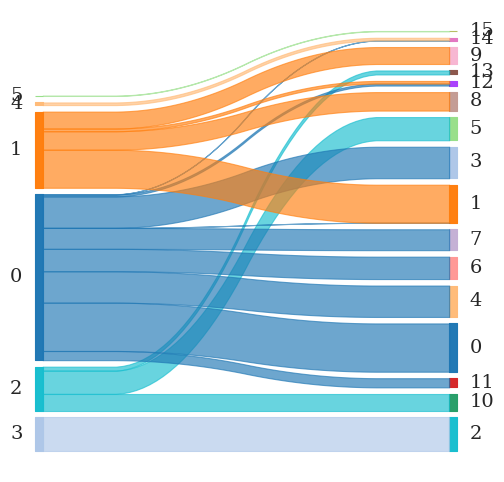

In [65]:
# Define the key you're using in UMAP and Sankey
key1 = "leiden_0.01_merged"
key2 = "leiden_0.1_merged"

# Get colors for each cluster from adata.uns
colors1 = adata.uns[f"{key1}_colors"]
labels1 = adata.obs[key1].cat.categories

colors2 = adata.uns[f"{key2}_colors"]
labels2 = adata.obs[key2].cat.categories

# Build colorDict by combining both sets (needed for both sides of the Sankey)
colorDict = {label: color for label, color in zip(labels1, colors1)}
colorDict.update({label: color for label, color in zip(labels2, colors2)})

sankey(adata.obs[key1], adata.obs[key2], colorDict=colorDict, threshold=10)
plt.savefig(figpath + "sankey_leiden_res_0.01_0.1.pdf")
plt.show()

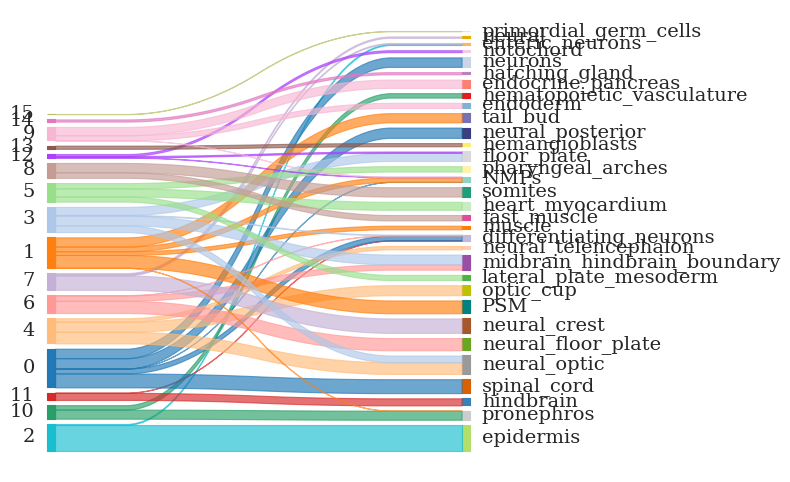

In [66]:
# Define the key you're using in UMAP and Sankey
# res1 = 0.1
# res2 = 0.8
# key1 = f"leiden_{res1}_merged"
# key2 = f"leiden_{res2}_merged"
res1 = 0.1
key1 = f"leiden_{res1}_merged"
res2 = "celltype"
key2 = "annotation_ML_coarse"

# Get colors for each cluster from adata.uns
colors1 = adata.uns[f"{key1}_colors"]
labels1 = adata.obs[key1].cat.categories

# colors2 = adata.uns[f"{key2}_colors"]
# labels2 = adata.obs[key2].cat.categories

# Build colorDict by combining both sets (needed for both sides of the Sankey)
colorDict = {label: color for label, color in zip(labels1, colors1)}
colorDict.update(cell_type_color_dict)

sankey(adata.obs[key1], adata.obs[key2], colorDict=colorDict, threshold=10)
plt.savefig(figpath + f"sankey_leiden_res_{res1}_{res2}.pdf")
plt.show()

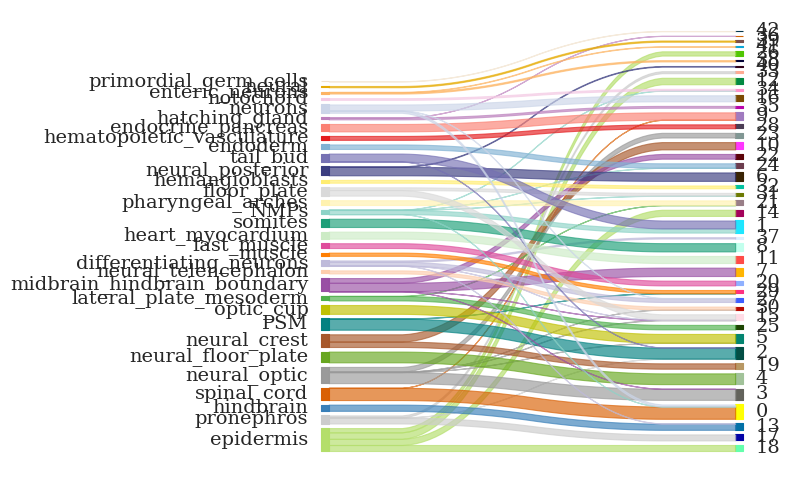

In [52]:
# Define the key you're using in UMAP and Sankey
# res1 = 0.1
# res2 = 0.8
# key1 = f"leiden_{res1}_merged"
# key2 = f"leiden_{res2}_merged"

res1 = "celltype"
key1 = "annotation_ML_coarse"
res2 = 0.8
key2 = f"leiden_{res2}_merged"

# Get colors for each cluster from adata.uns
colors2 = adata.uns[f"{key2}_colors"]
labels2 = adata.obs[key2].cat.categories

# Build colorDict by combining both sets (needed for both sides of the Sankey)
colorDict = {label: color for label, color in zip(labels2, colors2)}
colorDict.update(cell_type_color_dict)

sankey(adata.obs[key1], adata.obs[key2], colorDict=colorDict, threshold=10)
plt.savefig(figpath + f"sankey_leiden_res_{res1}_{res2}.pdf")

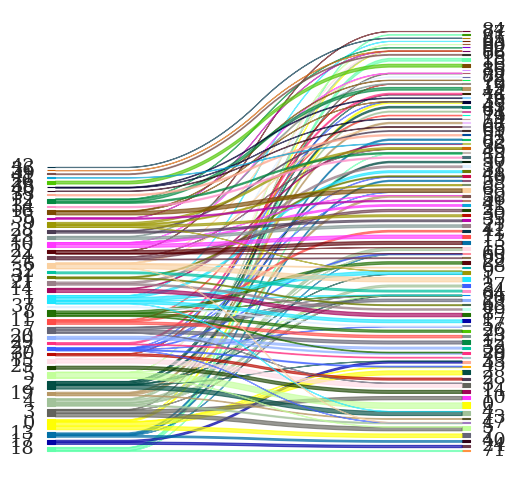

In [53]:
# Define the key you're using in UMAP and Sankey
res1 = 0.8
res2 = 3
key1 = f"leiden_{res1}_merged"
key2 = f"leiden_{res2}_merged"

# Get colors for each cluster from adata.uns
colors1 = adata.uns[f"{key1}_colors"]
labels1 = adata.obs[key1].cat.categories

colors2 = adata.uns[f"{key2}_colors"]
labels2 = adata.obs[key2].cat.categories

# Build colorDict by combining both sets (needed for both sides of the Sankey)
colorDict = {label: color for label, color in zip(labels1, colors1)}
colorDict.update({label: color for label, color in zip(labels2, colors2)})

sankey(adata.obs[key1], adata.obs[key2], colorDict=colorDict, threshold=10)
plt.savefig(figpath + f"sankey_leiden_res_{res1}_{res2}.pdf")